# EN3160 Assignment 01

## Intensity Transformations and Neighborhood Filtering

---

**Name:** R.A.C.D. Ranawaka    
**Index Number:** 230526A  
**GitHub Link:** https://github.com/chaniruranawaka/Intensity-Transformations-and-Neighborhood-Filtering


---

### Assignment Objective

This assignment investigates fundamental image processing techniques involving
intensity transformations and neighborhood filtering. The experiments explore
how different image enhancement and filtering techniques affect image
characteristics and visual quality.

### Q1. Intensity Transformation with Breakpoints

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

image_path = "data/input/q1.jpeg"

im = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if im is None:
    raise FileNotFoundError(f"Could not load image: {image_path}")

In [6]:
# Implementing the intensity transformation function
def intensity_transform(im, breakpoints):
    
    breakpoints = np.asarray(breakpoints, dtype=np.float32)

    input_values = breakpoints[:, 0]
    output_values = breakpoints[:, 1]

    transformed = np.interp(
        im.astype(np.float32),
        input_values,
        output_values
    )

    transformed = np.clip(transformed, 0, 255)

    return transformed.astype(np.uint8)

In [7]:
# Different Breakpoint Configurations
breakpoints_1a = np.array([
    [0,   0],
    [50,  50],
    [50, 100],
    [150, 255],
    [150, 150],
    [255, 255]
])

breakpoints_1 = np.array([
    [0,   0],
    [50,  25],
    [128, 128],
    [200, 230],
    [255, 255]
])

breakpoints_2 = np.array([
    [0,   20],
    [50,  55],
    [128, 140],
    [200, 220],
    [255, 255]
])

breakpoints_3 = np.array([
    [0,   0],
    [40,  65],
    [100, 145],
    [180, 220],
    [255, 255]
])

breakpoint_sets = {
    "Figure 1a": breakpoints_1a,
    "Custom 1": breakpoints_1,
    "Custom 2": breakpoints_2,
    "Custom 3": breakpoints_3
}

# Applying the intensity transformation to the image using different breakpoint configurations
transformed_images = {}

for name, breakpoints in breakpoint_sets.items():
    transformed_images[name] = intensity_transform(im, breakpoints)

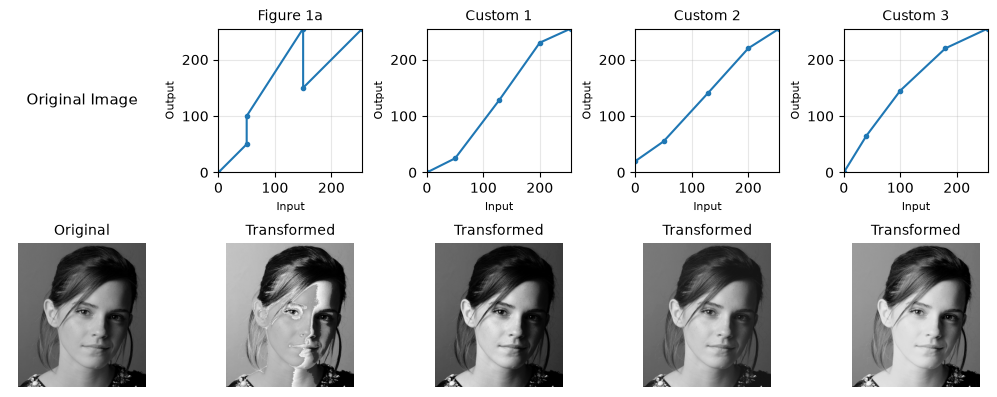

In [8]:
# Original image + intensity transformations
fig, axes = plt.subplots(
    2, 5,
    figsize=(10, 4)
)

# --------------------------------
# Original image
# --------------------------------

# Top-left: Original label
axes[0, 0].text(
    0.5, 0.5,
    "Original Image",
    ha="center",
    va="center",
    fontsize=11
)
axes[0, 0].axis("off")

# Bottom-left: Original image
axes[1, 0].imshow(
    im,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[1, 0].set_title("Original", fontsize=10)
axes[1, 0].axis("off")


# --------------------------------
# Four transformations
# --------------------------------

for i, (name, breakpoints) in enumerate(breakpoint_sets.items(), start=1):

    # Intensity transformation graph
    ax = axes[0, i]

    ax.plot(
        breakpoints[:, 0],
        breakpoints[:, 1],
        marker="o",
        linewidth=1.5,
        markersize=3
    )

    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Input", fontsize=8)
    ax.set_ylabel("Output", fontsize=8)

    ax.set_xlim(0, 255)
    ax.set_ylim(0, 255)
    ax.grid(True, alpha=0.3)

    # Transformed image
    ax = axes[1, i]

    ax.imshow(
        transformed_images[name],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    ax.set_title("Transformed", fontsize=10)
    ax.axis("off")


plt.tight_layout(pad=0.8)
plt.show()

**Observation:** The intensity transformation function was implemented using different breakpoint configurations and applied to the grayscale input image. The resulting transformation curves demonstrate how modifying the input–output intensity relationship can enhance or alter different intensity ranges of the image.

### Q2. Intensity Transformation for Brain Tissue Enhancement

In [9]:
# Load the image
image_path_q2 = "data/input/q2.jpeg"

brain = cv2.imread(
    image_path_q2,
    cv2.IMREAD_GRAYSCALE
)

if brain is None:
    raise FileNotFoundError(f"Could not load image: {image_path_q2}")

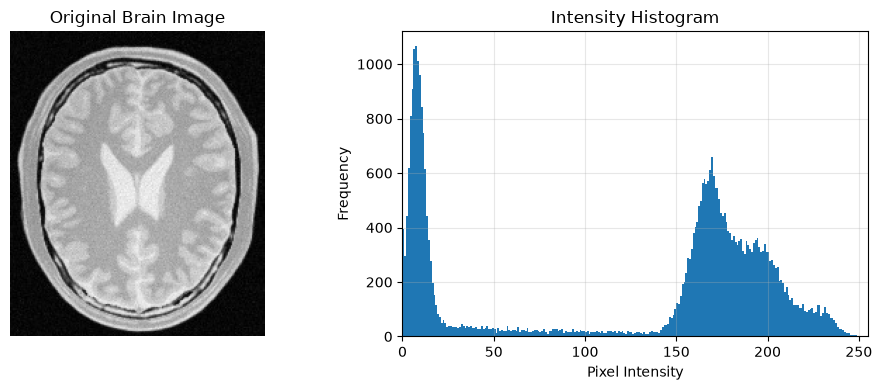

In [12]:
# Display the original brain image alongside its intensity histogram

fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4)
)

# -------------------------------
# Original brain image
# -------------------------------

axes[0].imshow(
    brain,
    cmap="gray",
    vmin=0,
    vmax=255
)

axes[0].set_title("Original Brain Image")
axes[0].axis("off")


# -------------------------------
# Intensity histogram
# -------------------------------

axes[1].hist(
    brain.ravel(),
    bins=256,
    range=(0, 256)
)

axes[1].set_title("Intensity Histogram")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Frequency")

axes[1].set_xlim(0, 255)
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

**Observation:** 
The histogram shows a low-intensity region around **0–50**, corresponding mainly to the background, and a broad tissue distribution from approximately **135–251**. Visual inspection shows that **gray matter is prominent around 135–190**, while **white matter is prominent around 190–251**. These ranges are selected for the respective intensity transformations.


#### 2.(a) White Matter

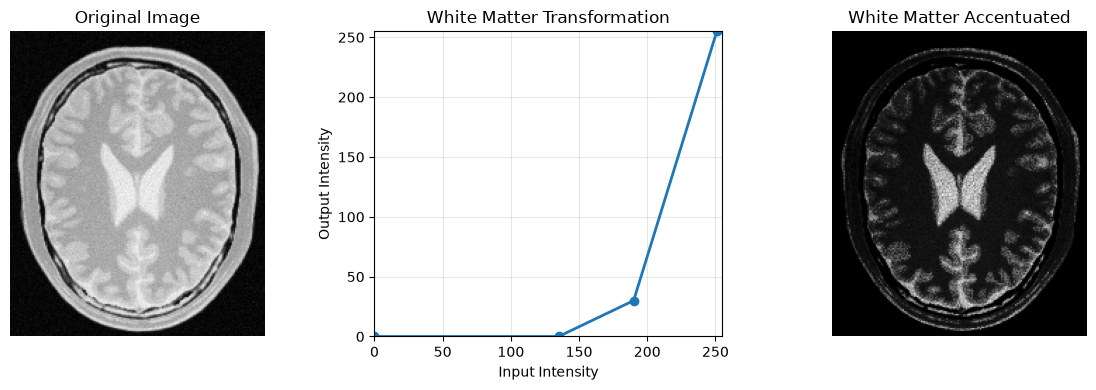

In [22]:
# Breakpoints for white matter enhancement
white_matter_breakpoints = np.array([
    [0,   0],
    [135, 0],
    [190, 30],
    [251, 255]
])

# Apply white matter intensity transformation
white_matter_enhanced = intensity_transform(
    brain,
    white_matter_breakpoints
)

# Display original image, transformation plot, and result
fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4)
)

# Original image
axes[0].imshow(
    brain,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[0].set_title("Original Image")
axes[0].axis("off")


# Intensity transformation
axes[1].plot(
    white_matter_breakpoints[:, 0],
    white_matter_breakpoints[:, 1],
    marker="o",
    linewidth=2
)
axes[1].set_title("White Matter Transformation")
axes[1].set_xlabel("Input Intensity")
axes[1].set_ylabel("Output Intensity")
axes[1].set_xlim(0, 255)
axes[1].set_ylim(0, 255)
axes[1].grid(True, alpha=0.3)


# Transformed image
axes[2].imshow(
    white_matter_enhanced,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[2].set_title("White Matter Accentuated")
axes[2].axis("off")

plt.tight_layout()
plt.show()

#### 2.(b) Gray Matter

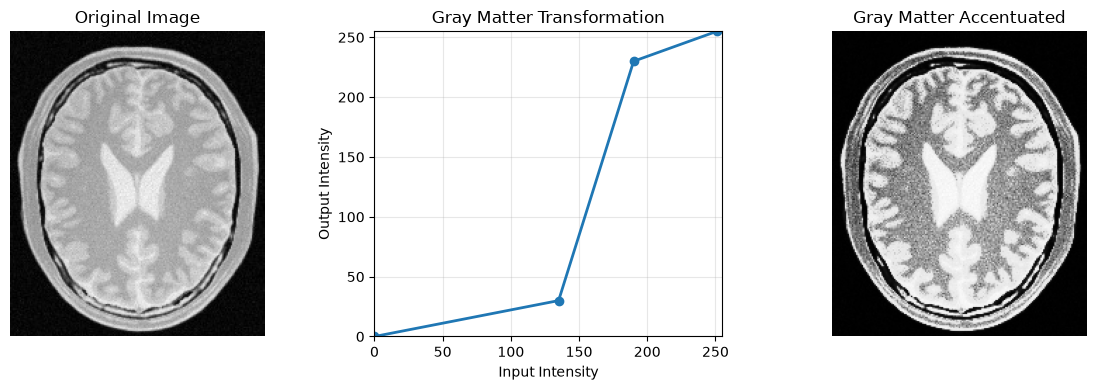

In [23]:
# Breakpoints for gray matter enhancement
gray_matter_breakpoints = np.array([
    [0,   0],
    [135, 30],
    [190, 230],
    [251, 255]
])

# Apply gray matter intensity transformation
gray_matter_enhanced = intensity_transform(
    brain,
    gray_matter_breakpoints
)

# Display original image, transformation plot, and result
fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4)
)

# Original image
axes[0].imshow(
    brain,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[0].set_title("Original Image")
axes[0].axis("off")


# Intensity transformation
axes[1].plot(
    gray_matter_breakpoints[:, 0],
    gray_matter_breakpoints[:, 1],
    marker="o",
    linewidth=2
)
axes[1].set_title("Gray Matter Transformation")
axes[1].set_xlabel("Input Intensity")
axes[1].set_ylabel("Output Intensity")
axes[1].set_xlim(0, 255)
axes[1].set_ylim(0, 255)
axes[1].grid(True, alpha=0.3)


# Transformed image
axes[2].imshow(
    gray_matter_enhanced,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[2].set_title("Gray Matter Accentuated")
axes[2].axis("off")

plt.tight_layout()
plt.show()

**Observation:** The piecewise-linear intensity transformations successfully accentuated the desired brain tissues. The 135–190 intensity range enhanced the visibility of gray matter, while the 190–251 range emphasized white matter by increasing the contrast within each selected intensity range.


### Q3. Gamma Correction

In [24]:
image_path_q3 = "data/input/WhatsApp Image 2026-09-09 at 20.02.44 (1).jpeg"

image = cv2.imread(image_path_q3)

if image is None:
    raise FileNotFoundError(f"Could not load image: {image_path_q3}")

* The image is converted from BGR to L* a* b* color space, and the L* plane is extracted for gamma correction.

In [25]:
# Convert BGR image to L*a*b* color space
lab = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2LAB
)

# Split into L*, a*, and b* planes
L, a, b = cv2.split(lab)

#### 3.(a) Apply gamma correction

In [34]:
# Gamma values to compare
gamma_values = [0.5, 0.7, 0.9, 1.0, 1.2]

gamma_results = {}

for gamma in gamma_values:

    # Normalize L* to [0, 1]
    L_normalized = L / 255.0

    # Apply gamma correction
    L_gamma = np.power(
        L_normalized,
        gamma
    )

    # Convert back to 8-bit
    L_corrected = np.uint8(
        L_gamma * 255
    )

    # Store result
    gamma_results[gamma] = L_corrected

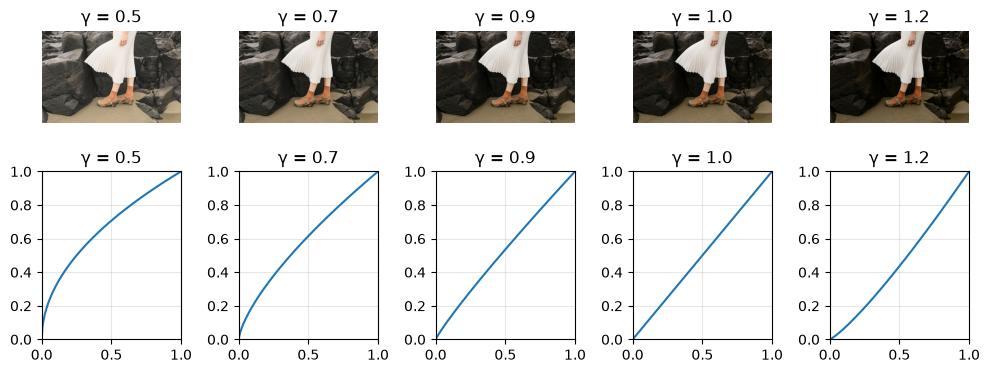

In [35]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

r = np.linspace(0, 1, 256)

for i, gamma in enumerate(gamma_values):

    # Corrected image
    lab_temp = cv2.merge([gamma_results[gamma], a, b])
    corrected = cv2.cvtColor(lab_temp, cv2.COLOR_LAB2BGR)

    axes[0, i].imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f"γ = {gamma}")
    axes[0, i].axis("off")

    # Gamma transformation
    axes[1, i].plot(r, r**gamma)
    axes[1, i].set_title(f"γ = {gamma}")
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_ylim(0, 1)
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observation:** The results show that decreasing γ below 1 increases the brightness of the image, while increasing γ above 1 produces a darker result. The transformation curves also show this change in the mapping of L* intensity values.

* Among the tested values, γ = 0.7 provides the most suitable enhancement for the given image.

#### 3.(b) Histograms of original and gamma corrected image

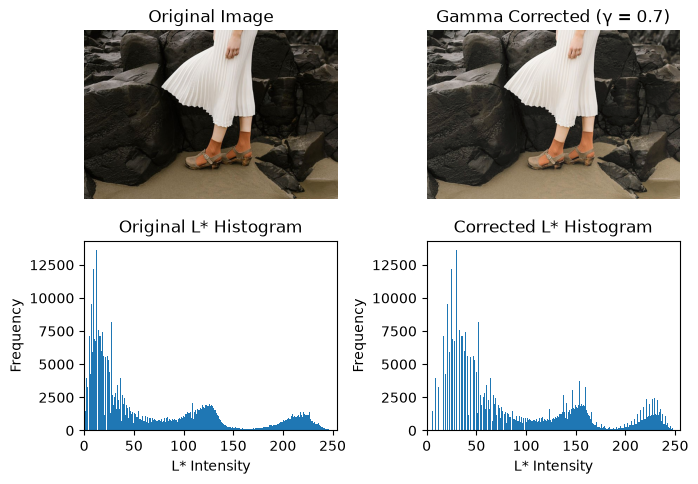

In [36]:
gamma = 0.7

# Apply gamma correction to L*
L_corrected = np.uint8(
    (L / 255.0) ** gamma * 255
)

# Reconstruct L*a*b*
lab_corrected = cv2.merge([
    L_corrected,
    a,
    b
])

# Convert back to BGR
corrected_image = cv2.cvtColor(
    lab_corrected,
    cv2.COLOR_LAB2BGR
)

# Display images and histograms
fig, axes = plt.subplots(
    2, 2,
    figsize=(7, 5)
)

# Original image
axes[0, 0].imshow(
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

# Gamma corrected image
axes[0, 1].imshow(
    cv2.cvtColor(corrected_image, cv2.COLOR_BGR2RGB)
)
axes[0, 1].set_title("Gamma Corrected (γ = 0.7)")
axes[0, 1].axis("off")

# Original L* histogram
axes[1, 0].hist(
    L.ravel(),
    bins=256,
    range=(0, 256)
)
axes[1, 0].set_title("Original L* Histogram")
axes[1, 0].set_xlabel("L* Intensity")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_xlim(0, 255)

# Corrected L* histogram
axes[1, 1].hist(
    L_corrected.ravel(),
    bins=256,
    range=(0, 256)
)
axes[1, 1].set_title("Corrected L* Histogram")
axes[1, 1].set_xlabel("L* Intensity")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_xlim(0, 255)

plt.tight_layout()
plt.show()

**Observation:** With **γ = 0.7**, the darker L* intensity values are expanded, resulting in a brighter image. The corrected histogram shows the corresponding shift of the L* intensity distribution toward higher values.
